# Homework

## Part 1

### Considerations

1. Labeling threshold  
    Define the decision threshold for mapping continuous predictions to binary labels.

2. Normalization of objective terms  
    - Term 1 (labeled–unlabeled consistency): divide by the number of labeled samples L.  
    - Term 2 (unlabeled–unlabeled consistency): divide by 2U (twice the number of unlabeled samples) to avoid double counting.

3. Similarity function selection  
    Choose and parameterize a kernel or distance measure (e.g. RBF kernel, Euclidean distance) for computing  
    W and W_tilde.

4. BCGD step‐size & priority rules  
    - Step‐size options: global Lipschitz constant, block‐wise Lipschitz constant or exact line search.  
    - Priority criteria: absolute gradient magnitude, normalized gradient or estimated maximum improvement.

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import rbf_kernel, euclidean_distances
from abc import ABC, abstractmethod
from typing import List, Callable

In [2]:
class SemiSupervisedLearner(ABC):
    """
    Base abstract class for semi-supervised learning algorithms
    """

    def __init__(self, similarity_function: Callable = None, max_iter: int = 1000, tol: float = 0.0001):
        """
        Initialize the base semi-supervised learner

        Parameters:
        -----------
        similarity_function: callable
            Function to compute similarity between data points
        """
        self.X_labeled = None
        self.y_labeled = None
        self.X_unlabeled = None
        self.y_pred = None

        self.similarity_function = similarity_function

        self.max_iter = max_iter
        self.tol = tol
        self.loss_history = []

    def fit(self, X_labeled: np.ndarray, y_labeled: np.ndarray,
            X_unlabeled: np.ndarray) -> np.ndarray:
        """
        Fit the model and predict labels for unlabeled data

        Parameters:
        -----------
        X_labeled: array of shape (L, d)
            Labeled examples
        y_labeled: array of shape (L,)
            Labels for labeled examples
        X_unlabeled: array of shape (U, d)
            Unlabeled examples

        Returns:
        --------
        y_pred: array of shape (U,)
            Predicted labels for unlabeled examples
        """
        self.X_labeled = X_labeled
        self.y_labeled = y_labeled
        self.X_unlabeled = X_unlabeled

        # Compute similarity matrices
        self.W = self._compute_similarity_labeled_unlabeled()
        self.W_tilde = self._compute_similarity_unlabeled_unlabeled()

        # Solve the optimization problem
        self.y_pred = self._solve_optimization()

        return self.y_pred

    def _compute_similarity_labeled_unlabeled(self) -> np.ndarray:
        """
        Compute similarity matrix between labeled and unlabeled examples

        Returns:
        --------
        W: array of shape (L, U)
            Similarity matrix between labeled and unlabeled examples
        """
        return self.similarity_function(self.X_labeled, self.X_unlabeled)

    def _compute_similarity_unlabeled_unlabeled(self) -> np.ndarray:
        """
        Compute similarity matrix between unlabeled examples excluding self-similarity

        Returns:
        --------
        W_tilde: array of shape (U, U)
            Similarity matrix between unlabeled examples
        """
        W_tilde = self.similarity_function(self.X_unlabeled, self.X_unlabeled)

        # Set diagonal to zero to exclude self-similarity
        np.fill_diagonal(W_tilde, 0)

        return W_tilde

    @abstractmethod
    def _solve_optimization(self) -> np.ndarray:
        """
        Solve the optimization problem to find labels for unlabeled examples

        Returns:
        --------
        y_pred: array of shape (U,)
            Predicted labels for unlabeled examples
        """
        pass

    def objective_function(self, y_pred: np.ndarray) -> float:
        """
        Compute the objective function value for the current solution

        f(y_pred) = (1/L)*∑∑ W[i, j]*(y_pred[j]-y[i])^2 + (1/(2*U)))*∑∑ W_tilde[i, j]*(y_pred[i]-y_pred[j])^2

        Parameters:
        -----------
        y_pred: array of shape (U,)
            Current solution for unlabeled examples

        Returns:
        --------
        obj_value: float
            Value of the objective function
        """
        L = len(self.X_labeled)
        U = len(self.X_unlabeled)

        # Term 1: Unlabeled examples similar to labeled ones get similar labels
        # Divide by L to normalize the term
        term1 = np.sum(self.W * (y_pred[np.newaxis, :] - self.y_labeled[:, np.newaxis])**2) / L

        # Term 2: Similar unlabeled examples get similar labels
        # Divide by U to normalize the term and by 2 to avoid double counting
        term2 = np.sum(self.W_tilde * (y_pred[np.newaxis, :] - y_pred[:, np.newaxis])**2) / (2 * U)

        return term1 + term2

    def _gradient(self, y_pred: np.ndarray, j: int) -> np.ndarray:
        """
        Compute the gradient of the objective function with respect to y_pred[j]

        ∇_y_pred[j]_f(y_pred) = (2/L)*∑ W[i, j]*(y_pred[j]-y[i]) + (2/U)*∑ W_tilde[i, j]*(y_pred[j]-y_pred[i])

        Parameters:
        -----------
        y_pred: array of shape (U,)
            Current solution for unlabeled examples
        j: int
            Index of the unlabeled example for which to compute the gradient

        Returns:
        --------
        grad: float
            Gradient of the objective function with respect to y_pred[j]
        """
        L = len(self.X_labeled)
        U = len(self.X_unlabeled)

        # Gradient from Term 1
        grad_term_1 = 2 * np.sum(self.W[:, j] * (y_pred[j] - self.y_labeled)) / L

        # Gradient from Term 2
        grad_term_2 = 2 * np.sum(self.W_tilde[j, :] * (y_pred[j] - y_pred)) / U

        return grad_term_1 + grad_term_2

    def gradient(self, y_pred: np.ndarray) -> np.ndarray:
        """
        Compute the gradient of the objective function

        Parameters:
        -----------
        y_pred: array of shape (U,)
            Current solution for unlabeled examples

        Returns:
        --------
        grad: array of shape (U,)
            Gradient of the objective function
        """
        L = len(self.X_labeled)
        U = len(self.X_unlabeled)

        grad = np.zeros(U)

        for j in range(U):
            # Compute the gradient for each unlabeled example
            grad[j] = self._gradient(y_pred, j)

        return grad

In [3]:
class GradientDescentSolver(SemiSupervisedLearner):
    """
    Semi-supervised learner using gradient descent
    """
    def __init__(self, similarity_function: Callable = None, max_iter: int = 1000, tol: float = 0.0001, stepsize=0.01, line_search_strat='fixed'):
        super().__init__(similarity_function, max_iter, tol)

        self.stepsize = stepsize
        self.line_search_strat = line_search_strat  # Armijo | exact | fixed

    def _get_stepsize(self) -> float:
        if self.line_search_strat == 'fixed':
            return self.stepsize
        elif self.line_search_strat == 'armijo':
            pass
        elif self.line_search_strat == 'exact':
            pass
        else:
            raise ValueError('Invalid line search strategy')

    def _solve_optimization(self) -> np.ndarray:
        """
        Solve the optimization problem using gradient descent
        
        Returns:
        --------
        y_pred: array of shape (U,)
            Predicted labels for unlabeled examples
        """
        U = len(self.X_unlabeled)
        
        # Initialize with zeros
        y_pred = np.zeros(U)
        
        # Gradient descent
        for i in range(self.max_iter):
            grad = self.gradient(y_pred)
            
            stepsize = self._get_stepsize()

            y_new = y_pred - stepsize * grad
            
            # Compute loss
            loss = self.objective_function(y_pred)
            self.loss_history.append(loss)
            
            # Check convergence
            if np.linalg.norm(y_new - y_pred) < self.tol:
                y_pred = y_new
                break
                
            y_pred = y_new
            
        return y_pred

In [4]:
class BlockCoordinateGDSolver(SemiSupervisedLearner):
    """
    Semi-supervised learner using Block Coordinate Gradient Descent with Gauss-Southwell rule
    """
    def __init__(self, similarity_function: Callable = None, max_iter: int = 1000, tol: float = 0.0001, block_size: int = 1, priority_strat='abs', stepsize_strat='L'):
        super().__init__(similarity_function, max_iter, tol)

        self.block_size = block_size
        self.priority_strat = priority_strat    # abs | abs_L | max_improvement
        self.stepsize_strat = stepsize_strat    # L | block_L | exact

    def _get_stepsize(self):
        if self.stepsize_strat == 'L':
            pass
        elif self.stepsize_strat == 'block_L':
            pass
        elif self.stepsize_strat == 'exact':
            pass
        else:
            raise ValueError('Invalid stepsize strategy')

    def _get_priority(self, grad: np.ndarray) -> List[int]:
        if self.priority_strat == 'abs':
            pass
        elif self.priority_strat == 'abs_L':
            pass
        elif self.priority_strat == 'max_improvement':
            pass
        else:
            raise ValueError('Invalid priority strategy')

    def _solve_optimization(self) -> np.ndarray:
        """
        Solve the optimization problem using Block Coordinate GD with Gauss-Southwell rule
        
        Returns:
        --------
        y_pred: array of shape (U,)
            Predicted labels for unlabeled examples
        """
        U = len(self.X_unlabeled)
        
        # Initialize with zeros
        y_pred = np.zeros(U)
        
        # Block Coordinate GD with Gauss-Southwell rule
        for i in range(self.max_iter):
            grad = self.gradient(y_pred)

            indices = self._get_priority(grad)

            stepsize = self._get_stepsize()

            # Update only selected coordinates
            y_new = y_pred.copy()
            y_new[indices] = y_pred[indices] - stepsize * grad[indices]
            
            # Compute loss
            loss = self.objective_function(y_pred)
            self.loss_history.append(loss)

            # Check convergence
            if np.linalg.norm(y_new - y_pred) < self.tol:
                y_pred = y_new
                break
                
            y_pred = y_new
            
        return y_pred

In [5]:
class CoordinateMinimizationSolver(SemiSupervisedLearner):
    """
    Semi-supervised learner using Coordinate Minimization
    """
    def __init__(self, similarity_function: Callable = None, max_iter: int = 1000, tol: float = 0.0001, coordinate_selection='cyclic'):
        super().__init__(similarity_function, max_iter, tol)

        self.coordinate_selection = coordinate_selection    # cyclic | random

    def _coordinate_minimizer(self, y_pred: np.ndarray, j: int) -> float:
        """
        Find the minimizer for coordinate j while keeping others fixed

        y_pred[j] =  (∑ W[i, j]*y[i] + ∑ W_tilde[i, j]*y[i]) / (∑ W[i, j] + ∑ W_tilde[i, j]) 

        Parameters:
        -----------
        y_pred: array of shape (U,)
            Current solution for unlabeled examples
        j: int
            Index of the coordinate to optimize

        Returns:
        --------
        y_j_optimal: float
            Optimal value for coordinate j
        """
        L = len(self.X_labeled)
        U = len(self.X_unlabeled)

        return (np.sum(self.W[:, j] * self.y_labeled) / L + np.sum(self.W_tilde[:, j] * y_pred) / U) / (np.sum(self.W[:, j]) / L + np.sum(self.W_tilde[:, j]) / U)
    
    def _solve_optimization(self) -> np.ndarray:
        """
        Solve the optimization problem using coordinate minimization
        
        Returns:
        --------
        y_pred: array of shape (U,)
            Predicted labels for unlabeled examples
        """
        U = len(self.X_unlabeled)

        # Initialize with zeros
        y_pred = np.zeros(U)

        # Coordinate Minimization
        for i in range(self.max_iter):
            y_old = y_pred.copy()
            
            # Generate coordinate indices based on selection strategy
            if self.coordinate_selection == 'cyclic':
                coordinates = np.arange(U)
            elif self.coordinate_selection == 'random':
                coordinates = np.random.permutation(U)
            else:
                raise ValueError('Invalid coordinate selection strategy')
            
            # Update each coordinate
            for j in coordinates:
                y_pred[j] = self._coordinate_minimizer(y_pred, j)
            
            # Compute loss
            loss = self.objective_function(y_pred)
            self.loss_history.append(loss)
            
            # Check convergence
            if np.linalg.norm(y_pred - y_old) < self.tol:
                break
                
        return y_pred

In [6]:
def generate_dataset(n_samples: int = 200, labeled_ratio: float = 0.1, centers: List = [[0, 0], [3, 3]], cluster_std: float = 1.0, random_state: int = 42):
    """
    Generate a toy binary classification dataset for semi-supervised learning
    
    Parameters:
    -----------
    n_samples: int
        Total number of samples
    labeled_ratio: float
        Ratio of labeled examples (between 0 and 1)
    centers: array-like of shape (2, 2)
        The centers of the two clusters
    cluster_std: float or list of two floats
        The standard deviation of the clusters
    random_state: int
        Random seed for reproducibility
        
    Returns:
    --------
    X_labeled: array of shape (n_labeled, 2)
        Labeled examples
    y_labeled: array of shape (n_labeled,)
        Labels for labeled examples
    X_unlabeled: array of shape (n_samples - n_labeled, 2)
        Unlabeled examples
    y_true: array of shape (n_samples - n_labeled,)
        True labels for unlabeled examples (for evaluation)
    """
    np.random.seed(random_state)
    
    # Calculate number of labeled examples
    n_labeled = int(n_samples * labeled_ratio)
    
    centers = np.array(centers)
    assert centers.shape == (2, 2), "Centers must be a 2x2 array"
    
    # Handle cluster_std as scalar or list
    if np.isscalar(cluster_std):
        cluster_std = [cluster_std, cluster_std]

    # Generate samples per class
    n_per_cluster = n_samples // 2
    remainder = n_samples - 2 * n_per_cluster
    samples_per_cluster = [n_per_cluster, n_per_cluster + remainder]
    
    # Generate data
    X1 = np.random.randn(samples_per_cluster[0], 2) * cluster_std[0] + centers[0]
    y1 = np.zeros(samples_per_cluster[0])
    
    X2 = np.random.randn(samples_per_cluster[1], 2) * cluster_std[1] + centers[1]
    y2 = np.ones(samples_per_cluster[1])
    
    # Combine the clusters
    X = np.vstack([X1, X2])
    y = np.hstack([y1, y2])
    
    # Shuffle the data
    indices = np.random.permutation(n_samples)
    X = X[indices]
    y = y[indices]
    
    # Split into labeled and unlabeled sets
    X_labeled = X[:n_labeled]
    y_labeled = y[:n_labeled]
    X_unlabeled = X[n_labeled:]
    y_true = y[n_labeled:]
    
    return X_labeled, y_labeled, X_unlabeled, y_true

In [7]:
def calculate_accuracy(y_true: np.ndarray, y_pred: np.ndarray, threshold: float = 0.5) -> float:
    """
    Calculate the accuracy of predictions

    Parameters:
    -----------
    y_true: array of shape (n_samples,)
        True labels
    y_pred: array of shape (n_samples,)
        Predicted labels (continuous values)
    threshold: float
        Threshold for binary classification (default: 0.5)
    Returns:
    --------
    accuracy: float
        Accuracy of the predictions
    """
    # Convert continuous predictions to binary labels
    y_pred_binary = (y_pred > threshold).astype(int)
    return np.mean(y_true == y_pred_binary)

def plot_dataset(X_labeled, y_labeled, X_unlabeled, y_pred=None, y_true=None, threshold=0.5):
    """
    Plot the dataset with labeled and unlabeled examples

    Parameters:
    -----------
    X_labeled: array of shape (L, 2)
        Labeled examples
    y_labeled: array of shape (L,)
        Labels for labeled examples
    X_unlabeled: array of shape (U, 2)
        Unlabeled examples
    y_pred: array of shape (U,)
        Predicted labels for unlabeled examples
    y_true: array of shape (U,)
        True labels for unlabeled examples
    threshold: float
        Threshold for binary classification (default: 0.5)
    """
    plt.figure(figsize=(12, 5))

    # Plot data before labeling
    plt.subplot(1, 2, 1)
    plt.scatter(
        X_labeled[:, 0], X_labeled[:, 1], 
        c=y_labeled, 
        cmap='coolwarm',
        marker='o', edgecolors='k'
    )
    plt.scatter(
        X_unlabeled[:, 0], X_unlabeled[:, 1],
        c='gray', marker='.'
    )
    plt.title('Labeled and Unlabeled Examples')

    # Plot data after labeling (if available)
    if y_pred is not None:
        plt.subplot(1, 2, 2)
        plt.scatter(
            X_labeled[:, 0], X_labeled[:, 1], 
            c=y_labeled, 
            cmap='coolwarm',
            marker='o', edgecolors='k'
        )
        plt.scatter(
            X_unlabeled[:, 0], X_unlabeled[:, 1], 
            c=y_pred, 
            cmap='coolwarm', marker='.'
        )

        accuracy = None
        if y_true is not None:
            accuracy = calculate_accuracy(y_true, y_pred, threshold)
            plt.title(f'Predicted Labels (Accuracy: {accuracy:.2f})')
        else:
            plt.title('Predicted Labels')

    plt.tight_layout()
    plt.show()

    return accuracy if y_true is not None else None

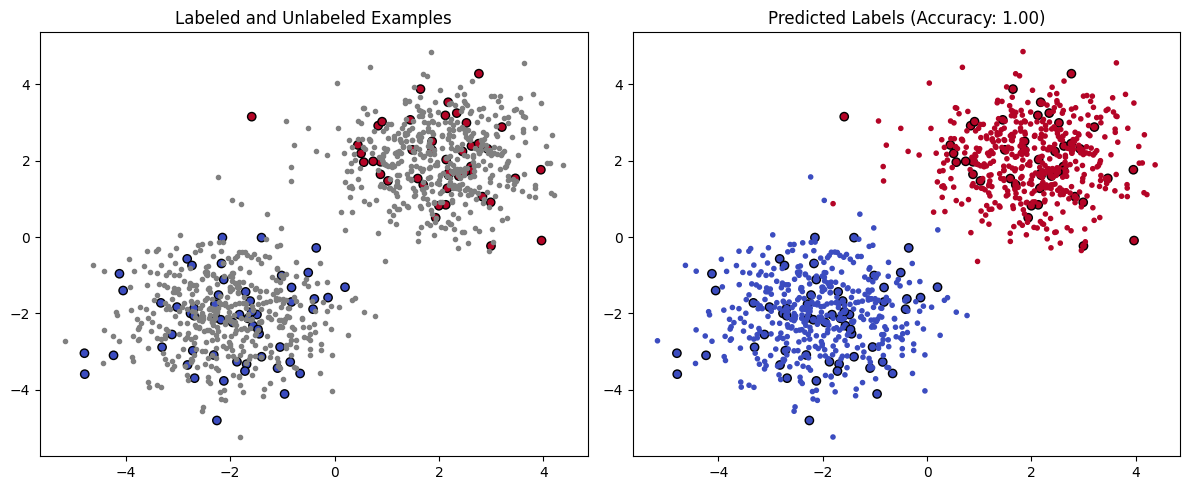

In [8]:
# Generating a dataset
X_labeled, y_labeled, X_unlabeled, y_true = generate_dataset(
    n_samples=1000, 
    labeled_ratio=0.1,
    centers=[[-2, -2], [2, 2]],
    random_state=123
)

# Plotting the dataset
accuracy = plot_dataset(
    X_labeled, y_labeled, X_unlabeled, 
    y_pred=y_true, y_true=y_true,
    threshold=0.5
)

## Part 2

GOOGLE DATASET SEARCH  (google search engine)
https://datasetsearch.research.google.com/

WIKIPEDIA PAGE ON DATASETS (wiki infos)

https://en.wikipedia.org/wiki/List_of_datasets_for_machine-learning_research

UCI DATASETS (ML repository)

https://archive.ics.uci.edu/ml/datasets.php

OTHER SOURCES

https://www.kaggle.com/datasets

https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary.html

https://www.cs.toronto.edu/~kriz/cifar.html

http://yann.lecun.com/exdb/mnist/

In [9]:
# testing on the public dataset